In [26]:
library(lme4)
library(ggplot2)
library(dplyr)
library(stringr)
library(tidyr)
library(ggpubr)
library(rstatix)
library(lubridate)
library(patchwork)
library(writexl)
library(tidyverse)
library(emmeans)
library(performance)
library(DHARMa)
library(glmmTMB)

# Genetic diversity analysis

In [2]:
# load the data with genetic diversity estimates per sample
rsva_diversity_matrix <- read.csv("../../../RSV_results/data_analysis/results/RSVA_2024_2025/genetic_diversity/Switzerland-RSV-A-2024-2025_genetic_diversity.csv",
                                 colClasses = c(location = "character"))

rsvb_diversity_matrix <- read.csv("../../../RSV_results/data_analysis/results/RSVB_2024_2025/genetic_diversity/Switzerland-RSV-B-2024-2025_genetic_diversity.csv",
                                 colClasses = c(location = "character"))


# merge genetic diversity dataframes
rsv_div_matrix <- rbind(rsva_diversity_matrix, rsvb_diversity_matrix)
# center the date
rsv_div_matrix <- rsv_div_matrix %>%
  mutate(location = factor(location)) %>%
  mutate(genome_region = factor(genome_region)) %>%
rename(ID = sample_id) %>%
select(-c(1)) %>%
mutate(date = as.Date(date, format = "%Y_%m_%d"))


# Filter out the samples that are covered less than 50% of the genome (or particular gene)
rsv_div_matrix <- rsv_div_matrix %>% filter(
  (covered_part >= 0.5)
)
rsv_div_matrix$location <- gsub("10", "Zurich", rsv_div_matrix$location)
rsv_div_matrix$location <- gsub("16", "Geneva", rsv_div_matrix$location)
rsv_div_matrix$location <- gsub("15", "Basel", rsv_div_matrix$location)
rsv_div_matrix$location <- gsub("05", "Lugano", rsv_div_matrix$location)
rsv_div_matrix$location <- gsub("25", "Laupen", rsv_div_matrix$location)
rsv_div_matrix$location <- gsub("17", "Chur", rsv_div_matrix$location)

rsv_div_matrix$subtype <- gsub("-", "_", rsv_div_matrix$subtype)

#rsv_div_matrix <- rsv_div_matrix %>%
  #group_by(genome_region)


In [3]:
# Add facet grouping
rsv_div_matrix <- rsv_div_matrix %>%
  mutate(
    facet_group = ifelse(genome_region == "genome", "Genome-wide", "Per-region")
  )

# Centering and scaling 
rsv_div_matrix <- rsv_div_matrix %>%
  group_by(facet_group) %>%   # optional: center per gene
  mutate(
    log_cov = log(mean_pos_coverage),
    log_cov_c = scale(log_cov, center = TRUE, scale = TRUE)[,1]          # centered and scaled
  ) %>%
  ungroup()

head(rsv_div_matrix)


ID,date,location,subtype,genome_region,nuc_diversity,covered_part,mean_pos_coverage,richness,facet_group,log_cov,log_cov_c
<chr>,<date>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
F1_10_2024_11_09,2024-11-09,Zurich,RSV_A,G,0.0001973822,0.6946170,2021.683,25.33532,Per-region,7.611686,-0.475385050
E1_10_2024_11_16,2024-11-16,Zurich,RSV_A,G,0.0013614424,0.5434783,3713.734,45.71429,Per-region,8.219793,0.003662707
A2_17_2024_11_24,2024-11-24,Chur,RSV_A,G,0.0011097650,0.9648033,8454.416,25.75107,Per-region,9.042444,0.651721217
A2_17_2024_11_24,2024-11-24,Chur,RSV_A,F,0.0019600457,0.6475362,3465.988,11.63832,Per-region,8.150753,-0.050724938
A2_17_2024_11_24,2024-11-24,Chur,RSV_A,genome,0.0011297796,0.6011823,2667.041,16.16956,Genome-wide,7.888725,-0.098982977
D1_10_2024_11_25,2024-11-25,Zurich,RSV_A,G,0.0018295970,0.6480331,4740.844,38.33866,Per-region,8.463970,0.196017847


##  Compare diversity between RSV-A and RSV-B subtypes and genome regions

In [4]:
rsv_div_matrix %>%
summarize(counts = n(),
         .by = c(genome_region, subtype))

genome_region,subtype,counts
<fct>,<chr>,<int>
G,RSV_A,76
F,RSV_A,51
genome,RSV_A,59
G,RSV_B,73
F,RSV_B,69
genome,RSV_B,45


## Diversity metrics: nucleotide diversity and richness per kb

In [5]:
rsv_div_matrix_genes <- rsv_div_matrix[rsv_div_matrix$genome_region %in% c("F", "G"), ]
head(rsv_div_matrix_genes)
summary(rsv_div_matrix_genes)

ID,date,location,subtype,genome_region,nuc_diversity,covered_part,mean_pos_coverage,richness,facet_group,log_cov,log_cov_c
<chr>,<date>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
F1_10_2024_11_09,2024-11-09,Zurich,RSV_A,G,0.0001973822,0.6946170,2021.683,25.33532,Per-region,7.611686,-0.475385050
E1_10_2024_11_16,2024-11-16,Zurich,RSV_A,G,0.0013614424,0.5434783,3713.734,45.71429,Per-region,8.219793,0.003662707
A2_17_2024_11_24,2024-11-24,Chur,RSV_A,G,0.0011097650,0.9648033,8454.416,25.75107,Per-region,9.042444,0.651721217
A2_17_2024_11_24,2024-11-24,Chur,RSV_A,F,0.0019600457,0.6475362,3465.988,11.63832,Per-region,8.150753,-0.050724938
D1_10_2024_11_25,2024-11-25,Zurich,RSV_A,G,0.0018295970,0.6480331,4740.844,38.33866,Per-region,8.463970,0.196017847
D1_10_2024_11_25,2024-11-25,Zurich,RSV_A,F,0.0002039714,0.8655072,2642.370,11.38647,Per-region,7.879432,-0.264463253


      ID                 date              location           subtype         
 Length:269         Min.   :2024-11-09   Length:269         Length:269        
 Class :character   1st Qu.:2024-12-29   Class :character   Class :character  
 Mode  :character   Median :2025-01-24   Mode  :character   Mode  :character  
                    Mean   :2025-01-25                                        
                    3rd Qu.:2025-02-22                                        
                    Max.   :2025-04-16                                        
 genome_region nuc_diversity        covered_part    mean_pos_coverage 
 F     :120    Min.   :0.0000159   Min.   :0.5020   Min.   :   34.13  
 G     :149    1st Qu.:0.0004635   1st Qu.:0.6168   1st Qu.: 1992.39  
 genome:  0    Median :0.0015761   Median :0.7316   Median : 4740.84  
               Mean   :0.0031511   Mean   :0.7392   Mean   : 6467.94  
               3rd Qu.:0.0044730   3rd Qu.:0.8521   3rd Qu.: 9241.92  
               Max.  

In [6]:
genes <- c("F", "G")
metrics <- c("nuc_diversity")

# Per-gene models: compare subtypes within gene
for(g in genes){
  for(m in metrics){
    formula <- as.formula(paste(m, "~ subtype + (1|location) + log_cov_c + I(log_cov_c^2)"))
    assign(paste0(m, "_", g),
           glmmTMB(formula,
                   family = Gamma(link = "log"),
                   data = rsv_div_matrix[
                     rsv_div_matrix$genome_region == g, ]))
  }
}


metrics <- c("nuc_diversity", "richness")

# RSV-A only: compare F vs G
for(m in metrics){
  formula <- as.formula(paste(m, "~ genome_region + (1|location) + log_cov_c + I(log_cov_c^2)"))
  assign(paste0(m, "_RSV_A"),
         glmmTMB(formula,
                 family = Gamma(link = "log"),
                 data = rsv_div_matrix_genes[
                   rsv_div_matrix_genes$subtype == "RSV_A", ]))
}

# RSV-B only: compare F vs G
for(m in metrics){
  formula <- as.formula(paste(m, "~ genome_region + (1|location) + log_cov_c + I(log_cov_c^2)"))
  assign(paste0(m, "_RSV_B"),
         glmmTMB(formula,
                 family = Gamma(link = "log"),
                 data = rsv_div_matrix_genes[
                   rsv_div_matrix_genes$subtype == "RSV_B", ]))
}


In [7]:
metrics <- c("nuc_diversity")

for(m in metrics){
  formula <- as.formula(paste(m, "~ subtype + (1|location) + log_cov_c + I(log_cov_c^2)"))
  assign(paste0(m, "_full_genome"),
         glmmTMB(formula,
                 family = Gamma(link = "log"),
                 data = rsv_div_matrix[
                     rsv_div_matrix$genome_region == "genome", ]))
}



In [8]:
# Goals - subtype constrast within full-genome
genome_models <- list(
    nuc_diversity_full_genome = nuc_diversity_full_genome
)

# Goals - subtype contrast within each gene
gene_models <- list(
  nuc_diversity_F = nuc_diversity_F,
  nuc_diversity_G = nuc_diversity_G
)

# Goals - gene contrast within each subtype
subtype_models <- list(
  nuc_diversity_RSV_A = nuc_diversity_RSV_A,
  nuc_diversity_RSV_B = nuc_diversity_RSV_B,
  richness_RSV_A      = richness_RSV_A,
  richness_RSV_B      = richness_RSV_B
)

# extraction function 
extract_emmeans <- function(model, model_name, predictor) {
  emm  <- emmeans(model, as.formula(paste("~", predictor)), 
                  type = "response")
  cont <- pairs(emm, type = "response")
  
  list(
    means     = as.data.frame(emm)  %>% mutate(model = model_name),
    contrasts = as.data.frame(cont) %>% mutate(model = model_name)
  )
}

# Apply — note predictor differs between the two sets
results_genomes    <- lapply(names(genome_models), function(n)
  extract_emmeans(genome_models[[n]],    n, "subtype"))

results_genes    <- lapply(names(gene_models), function(n)
  extract_emmeans(gene_models[[n]],    n, "subtype"))

results_subtypes <- lapply(names(subtype_models), function(n)
  extract_emmeans(subtype_models[[n]], n, "genome_region"))

# Combine contrasts
contrasts_genomes  <- bind_rows(lapply(results_genomes,    `[[`, "contrasts"))
contrasts_genes    <- bind_rows(lapply(results_genes,    `[[`, "contrasts"))
contrasts_subtypes <- bind_rows(lapply(results_subtypes, `[[`, "contrasts"))

# Correct for multiple testing separately within each comparison type
contrasts_genomes <- contrasts_genomes %>%
  mutate(p.adjusted = p.adjust(p.value, method = "BH"))

contrasts_genes <- contrasts_genes %>%
  mutate(p.adjusted = p.adjust(p.value, method = "BH"))

contrasts_subtypes <- contrasts_subtypes %>%
  mutate(p.adjusted = p.adjust(p.value, method = "BH"))

In [9]:
descriptives_formatted <- rsv_div_matrix %>%
  filter(genome_region %in% c("genome", "F", "G")) %>%
  group_by(subtype, genome_region) %>%
  summarise(
    n = n(),
    across(
      c(nuc_diversity, richness),
      list(
        median = ~ round(median(.), 4),
        Q1     = ~ round(quantile(., 0.25), 4),
        Q3     = ~ round(quantile(., 0.75), 4)
      )
    ),
    .groups = "drop"
  ) %>%
  mutate(
    Nucleotide_diversity   = paste0(nuc_diversity_median,
                               " (", nuc_diversity_Q1, "–", nuc_diversity_Q3, ")"),
    Richness               = paste0(richness_median,
                               " (", richness_Q1, "–", richness_Q3, ")")
  ) %>%
  select(genome_region, subtype, n,
         Nucleotide_diversity,
         Richness) %>%
  mutate(
    genome_region = case_when(
      genome_region == "genome" ~ "Whole genome",
      genome_region == "F"      ~ "F gene",
      genome_region == "G"      ~ "G gene"
    ),
    subtype = case_when(
      subtype == "RSV_A" ~ "RSV-A",
      subtype == "RSV_B" ~ "RSV-B"
    )
  ) %>%
  arrange(genome_region, subtype)
  write_xlsx(
    descriptives_formatted, 
    path = "descriptives_formatted.xlsx"
)

In [10]:
descriptives_formatted

genome_region,subtype,n,Nucleotide_diversity,Richness
<chr>,<chr>,<int>,<chr>,<chr>
F gene,RSV-A,51,0.0015 (7e-04–0.003),13.624 (11.1802–16.5856)
F gene,RSV-B,69,4e-04 (2e-04–8e-04),11.2782 (9.8551–13.3753)
G gene,RSV-A,76,0.0035 (0.0013–0.0076),37.0551 (31.041–45.0715)
G gene,RSV-B,73,0.0029 (7e-04–0.0061),31.1355 (25.641–35.7143)
Whole genome,RSV-A,59,0.0038 (0.0025–0.0045),20.3541 (18.4329–22.4529)
Whole genome,RSV-B,45,0.0018 (0.0011–0.0024),14.1156 (11.9168–15.1457)


In [11]:
# Add comparison type and parse model name
contrasts_all <- bind_rows(
  contrasts_genomes  %>% mutate(comparison_type = "Subtype, whole genome"),
  contrasts_genes    %>% mutate(comparison_type = "Subtype, gene level"),
  contrasts_subtypes %>% mutate(comparison_type = "Gene, within subtype")
) %>%
  # Parse metric and gene/subtype from model name
  mutate(
    metric = case_when(
      grepl("^nuc_diversity", model) ~ "Nucleotide diversity",
      grepl("^richness",      model) ~ "Richness"
    ),
    group = case_when(
      grepl("_F$",     model) ~ "F gene",
      grepl("_G$",     model) ~ "G gene",
      grepl("RSV_A$",  model) ~ "RSV-A",
      grepl("RSV_B$",  model) ~ "RSV-B",
      grepl("genome",  model) ~ "Whole genome"
    )
  )

In [12]:
results_table <- contrasts_all %>%
  select(comparison_type, group, contrast, metric, 
         ratio, SE, z.ratio, p.value, p.adjusted) %>%
  mutate(
    ratio      = round(ratio,      3),
    SE         = round(SE,         3),
    z.ratio    = round(z.ratio,    3),
    p.value    = p.value,
    p.adjusted = p.adjusted,
    significant = ifelse(p.adjusted < 0.05, "*", "")
  ) %>%
  arrange(comparison_type, group, contrast, metric)

print(results_table)

        comparison_type        group      contrast               metric ratio
1  Gene, within subtype        RSV-A         F / G Nucleotide diversity 0.582
2  Gene, within subtype        RSV-A         F / G             Richness 0.390
3  Gene, within subtype        RSV-B         F / G Nucleotide diversity 0.176
4  Gene, within subtype        RSV-B         F / G             Richness 0.371
5   Subtype, gene level       F gene RSV_A / RSV_B Nucleotide diversity 3.138
6   Subtype, gene level       G gene RSV_A / RSV_B Nucleotide diversity 1.021
7 Subtype, whole genome Whole genome RSV_A / RSV_B Nucleotide diversity 2.097
     SE z.ratio      p.value   p.adjusted significant
1 0.109  -2.883 3.943844e-03 3.943844e-03           *
2 0.018 -20.171 1.778002e-90 3.556005e-90           *
3 0.033  -9.373 7.042724e-21 9.390299e-21           *
4 0.018 -20.573 4.808816e-94 1.923526e-93           *
5 0.707   5.076 3.845152e-07 7.690305e-07           *
6 0.173   0.120 9.043609e-01 9.043609e-01           

In [13]:
means_all <- bind_rows(
  bind_rows(lapply(results_genomes,  `[[`, "means")) %>% 
    mutate(comparison_type = "Subtype, whole genome"),
  bind_rows(lapply(results_genes,    `[[`, "means")) %>% 
    mutate(comparison_type = "Subtype, gene level"),
  bind_rows(lapply(results_subtypes, `[[`, "means")) %>% 
    mutate(comparison_type = "Gene, within subtype")
) %>%
  mutate(
    metric = case_when(
      grepl("^nuc_diversity", model) ~ "Nucleotide diversity",
      grepl("^richness",      model) ~ "Richness"
    ),
    group = case_when(
      grepl("_F$",    model) ~ "F gene",
      grepl("_G$",    model) ~ "G gene",
      grepl("RSV_A$", model) ~ "RSV-A",
      grepl("RSV_B$", model) ~ "RSV-B",
      grepl("genome", model) ~ "Whole genome"
    )
  ) %>%
  mutate(
    across(c(response, asymp.LCL, asymp.UCL), ~ round(., 5))
  )

In [14]:
contrasts_all_clean <- contrasts_all %>%
  mutate(
    # Who was compared with whom — parsed from emmeans contrast column
    compared      = contrast,  # already contains "RSV_A / RSV_B" or "F / G"

    # Where — the data context
    genomic_level = case_when(
      comparison_type == "Subtype, whole genome" ~ "Whole genome",
      comparison_type == "Subtype, gene level"   ~ group,  # F gene or G gene
      comparison_type == "Gene, within subtype"  ~ group   # RSV-A or RSV-B
    ),

    # What is being tested
    fixed_effect = case_when(
      comparison_type %in% c("Subtype, whole genome",
                              "Subtype, gene level") ~ "Subtype",
      comparison_type == "Gene, within subtype"      ~ "Gene"
    )
  ) %>%
mutate(
    significant = ifelse(p.adjusted < 0.05, "*", "")
  ) %>%
  select(fixed_effect, genomic_level, metric,
         compared, ratio, SE, z.ratio, p.value, p.adjusted, significant)
contrasts_all_clean

fixed_effect,genomic_level,metric,compared,ratio,SE,z.ratio,p.value,p.adjusted,significant
<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Subtype,Whole genome,Nucleotide diversity,RSV_A / RSV_B,2.0965036,0.21297208,7.2872503,3.163448e-13,3.163448e-13,*
Subtype,F gene,Nucleotide diversity,RSV_A / RSV_B,3.1379127,0.70686636,5.0764681,3.845152e-07,7.690305e-07,*
Subtype,G gene,Nucleotide diversity,RSV_A / RSV_B,1.0205723,0.17296510,0.1201543,9.043609e-01,9.043609e-01,
Gene,RSV-A,Nucleotide diversity,F / G,0.5816526,0.10934052,-2.8826188,3.943844e-03,3.943844e-03,*
Gene,RSV-B,Nucleotide diversity,F / G,0.1764708,0.03265792,-9.3731084,7.042724e-21,9.390299e-21,*
Gene,RSV-A,Richness,F / G,0.3896733,0.01820709,-20.1705088,1.778002e-90,3.556005e-90,*
Gene,RSV-B,Richness,F / G,0.3711034,0.01788114,-20.5728188,4.808816e-94,1.923526e-93,*


In [15]:
means_all
contrasts_all_clean

subtype,response,SE,df,asymp.LCL,asymp.UCL,model,comparison_type,genome_region,metric,group
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<chr>,<chr>
RSV_A,0.00330,0.0003246337,Inf,0.00272,0.00400,nuc_diversity_full_genome,"Subtype, whole genome",NA,Nucleotide diversity,Whole genome
RSV_B,0.00158,0.0001840884,Inf,0.00125,0.00198,nuc_diversity_full_genome,"Subtype, whole genome",NA,Nucleotide diversity,Whole genome
RSV_A,0.00224,0.0004182905,Inf,0.00155,0.00323,nuc_diversity_F,"Subtype, gene level",NA,Nucleotide diversity,F gene
RSV_B,0.00071,0.0001237795,Inf,0.00051,0.00100,nuc_diversity_F,"Subtype, gene level",NA,Nucleotide diversity,F gene
RSV_A,0.00394,0.0005027636,Inf,0.00307,0.00506,nuc_diversity_G,"Subtype, gene level",NA,Nucleotide diversity,G gene
RSV_B,0.00386,0.0005073570,Inf,0.00298,0.00499,nuc_diversity_G,"Subtype, gene level",NA,Nucleotide diversity,G gene
NA,0.00213,0.0003232641,Inf,0.00159,0.00287,nuc_diversity_RSV_A,"Gene, within subtype",F,Nucleotide diversity,RSV-A
NA,0.00367,0.0005184885,Inf,0.00278,0.00484,nuc_diversity_RSV_A,"Gene, within subtype",G,Nucleotide diversity,RSV-A
NA,0.00070,0.0001163139,Inf,0.00051,0.00097,nuc_diversity_RSV_B,"Gene, within subtype",F,Nucleotide diversity,RSV-B


fixed_effect,genomic_level,metric,compared,ratio,SE,z.ratio,p.value,p.adjusted,significant
<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Subtype,Whole genome,Nucleotide diversity,RSV_A / RSV_B,2.0965036,0.21297208,7.2872503,3.163448e-13,3.163448e-13,*
Subtype,F gene,Nucleotide diversity,RSV_A / RSV_B,3.1379127,0.70686636,5.0764681,3.845152e-07,7.690305e-07,*
Subtype,G gene,Nucleotide diversity,RSV_A / RSV_B,1.0205723,0.17296510,0.1201543,9.043609e-01,9.043609e-01,
Gene,RSV-A,Nucleotide diversity,F / G,0.5816526,0.10934052,-2.8826188,3.943844e-03,3.943844e-03,*
Gene,RSV-B,Nucleotide diversity,F / G,0.1764708,0.03265792,-9.3731084,7.042724e-21,9.390299e-21,*
Gene,RSV-A,Richness,F / G,0.3896733,0.01820709,-20.1705088,1.778002e-90,3.556005e-90,*
Gene,RSV-B,Richness,F / G,0.3711034,0.01788114,-20.5728188,4.808816e-94,1.923526e-93,*


In [16]:
write_xlsx(
  list(
    marginal_means = means_all %>%
      select(comparison_type, subtype, genome_region, group, metric, 
             response, asymp.LCL, asymp.UCL),
    contrasts      = contrasts_all_clean
  ),
  path = "RSV_diversity_results.xlsx"
)

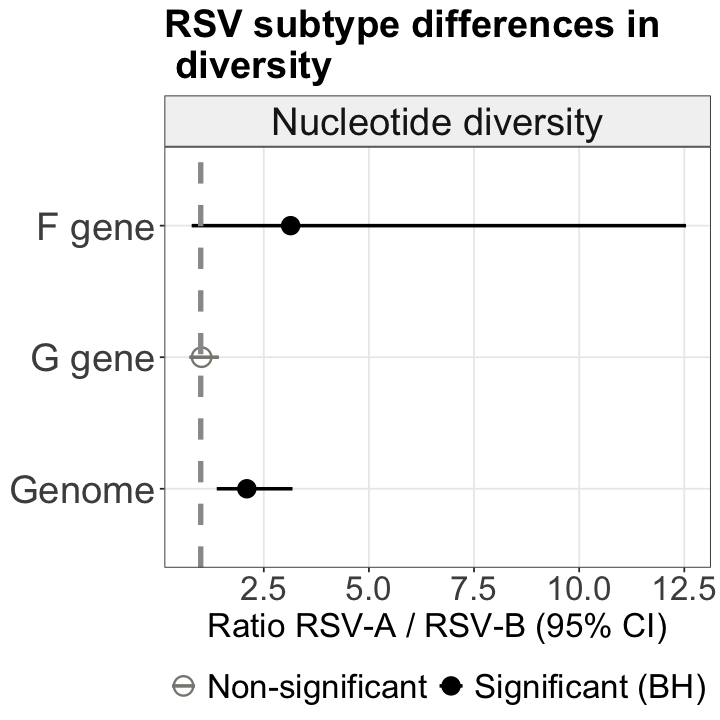

In [17]:
options(repr.plot.width = 6, repr.plot.height = 6)


# Prepare data
plot_subtypes <- bind_rows(
  contrasts_genomes %>% mutate(level = "Genome"),
  contrasts_genes   %>% mutate(level = case_when(
    grepl("_F$", model) ~ "F gene",
    grepl("_G$", model) ~ "G gene"
  ))
) %>%
  mutate(
    metric = case_when(
      grepl("^nuc_diversity", model) ~ "Nucleotide diversity",
      grepl("^richness",      model) ~ "Richness"
    ),
    level = factor(level, levels = c("Genome", "G gene", "F gene")),
    # confidence interval from SE on log scale
    lower = exp(log(ratio) - 1.96 * SE),
    upper = exp(log(ratio) + 1.96 * SE),
    significant = p.adjusted < 0.05
  )

figA <- ggplot(plot_subtypes, 
       aes(x = ratio, y = level, 
           xmin = lower, xmax = upper,
           colour = significant,
           shape  = significant)) +
  geom_pointrange(size = 1.2, linewidth = 1) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey60", linewidth = 1.5) +
  facet_wrap(~ metric, ncol = 1, scales = "free_x") +
  scale_colour_manual(
    values = c("TRUE" = "black", "FALSE" = "#888780"),
    labels = c("TRUE" = "Significant (BH)", "FALSE" = "Non-significant")
  ) +
  scale_shape_manual(
    values = c("TRUE" = 16, "FALSE" = 1),
    labels = c("TRUE" = "Significant (BH)", "FALSE" = "Non-significant")
  ) +
  labs(
    x      = "Ratio RSV-A / RSV-B (95% CI)",
    y      = NULL,
    colour = NULL,
    shape  = NULL,
    title  = "RSV subtype differences in \n diversity"
  ) +
  theme_bw(base_size = 20) +
theme_bw() +
  theme(
    text         = element_text(size = 20),      # all text base size
    axis.title   = element_text(size = 20),      # axis labels
    axis.text.x    = element_text(size = 20),      # axis tick labels
    axis.text.y    = element_text(size = 23),      # axis tick labels

    legend.text  = element_text(size = 20),      # legend items
    legend.title = element_text(size = 20),      # legend title
    plot.title   = element_text(size = 23,       # plot title
                                face = "bold"),
    strip.text   = element_text(size = 23),      # facet labels if any

    legend.position = "bottom",
    strip.background = element_rect(fill = "grey95"),
    panel.grid.minor = element_blank()
  )
ggsave("Figure4_A.pdf", figA, width = 6, height = 6)

figA 

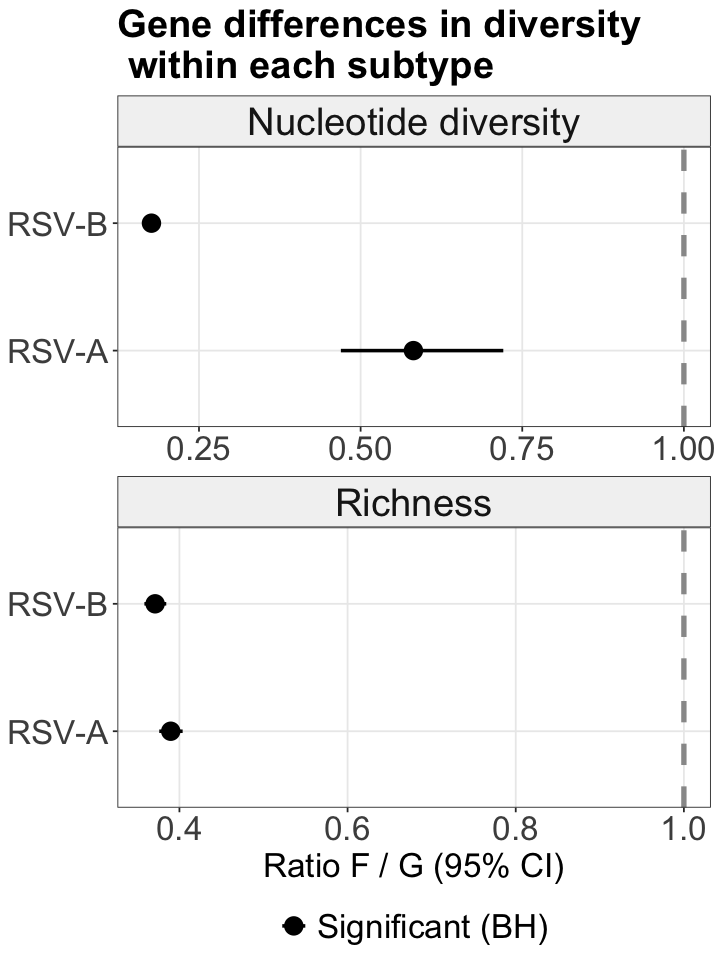

In [18]:
options(repr.plot.width = 6, repr.plot.height = 8)

plot_genes <- contrasts_subtypes %>%
  mutate(
    metric = case_when(
      grepl("^nuc_diversity", model) ~ "Nucleotide diversity",
      grepl("^richness",      model) ~ "Richness"
    ),
    subtype = case_when(
      grepl("RSV_A$", model) ~ "RSV-A",
      grepl("RSV_B$", model) ~ "RSV-B"
    ),
    lower = exp(log(ratio) - 1.96 * SE),
    upper = exp(log(ratio) + 1.96 * SE),
    significant = p.adjusted < 0.05
  )

figB <- ggplot(plot_genes,
       aes(x = ratio, y = subtype,
           xmin = lower, xmax = upper,
           colour = significant,
           shape  = significant)) +
  geom_pointrange(size = 1.2, linewidth = 1) +
  geom_vline(xintercept = 1, linetype = "dashed", colour = "grey60", linewidth = 1.5) +
  facet_wrap(~ metric, ncol = 1, scales = "free_x") +
  scale_colour_manual(
    values = c("TRUE" = "black", "FALSE" = "#888780"),
    labels = c("TRUE" = "Significant (BH)", "FALSE" = "Non-significant")
  ) +
  scale_shape_manual(
    values = c("TRUE" = 16, "FALSE" = 1),
    labels = c("TRUE" = "Significant (BH)", "FALSE" = "Non-significant")
  ) +
  labs(
    x      = "Ratio F / G (95% CI)",
    y      = NULL,
    colour = NULL,
    shape  = NULL,
    title  = "Gene differences in diversity \n within each subtype"
  ) +
  theme_bw(base_size = 20) +
theme_bw() +
theme(
    text         = element_text(size = 20),      # all text base size
    axis.title   = element_text(size = 20),      # axis labels
    axis.text    = element_text(size = 20),      # axis tick labels
    legend.text  = element_text(size = 20),      # legend items
    legend.title = element_text(size = 20),      # legend title
    plot.title   = element_text(size = 23,       # plot title
                                face = "bold"),
    strip.text   = element_text(size = 23),      # facet labels if any

    legend.position = "bottom",
    strip.background = element_rect(fill = "grey95"),
    panel.grid.minor = element_blank()
  )
ggsave("Figure4_B.pdf", figB, width = 6, height =9)
figB


Model: nuc_diversity_full_genome 

Model: nuc_diversity_F 


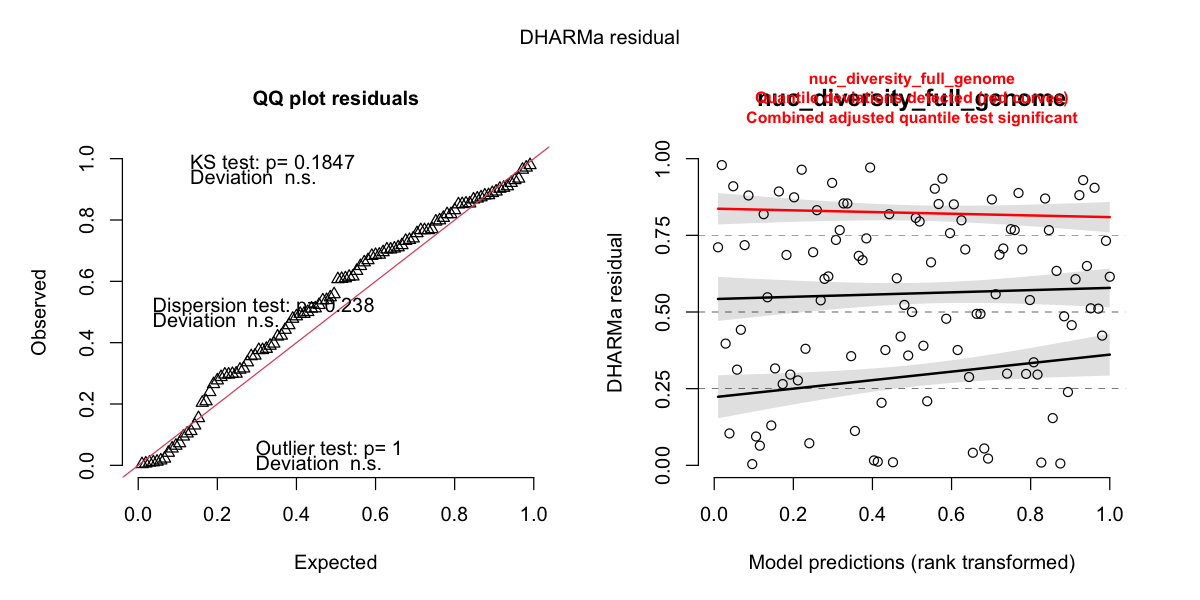


Model: nuc_diversity_G 


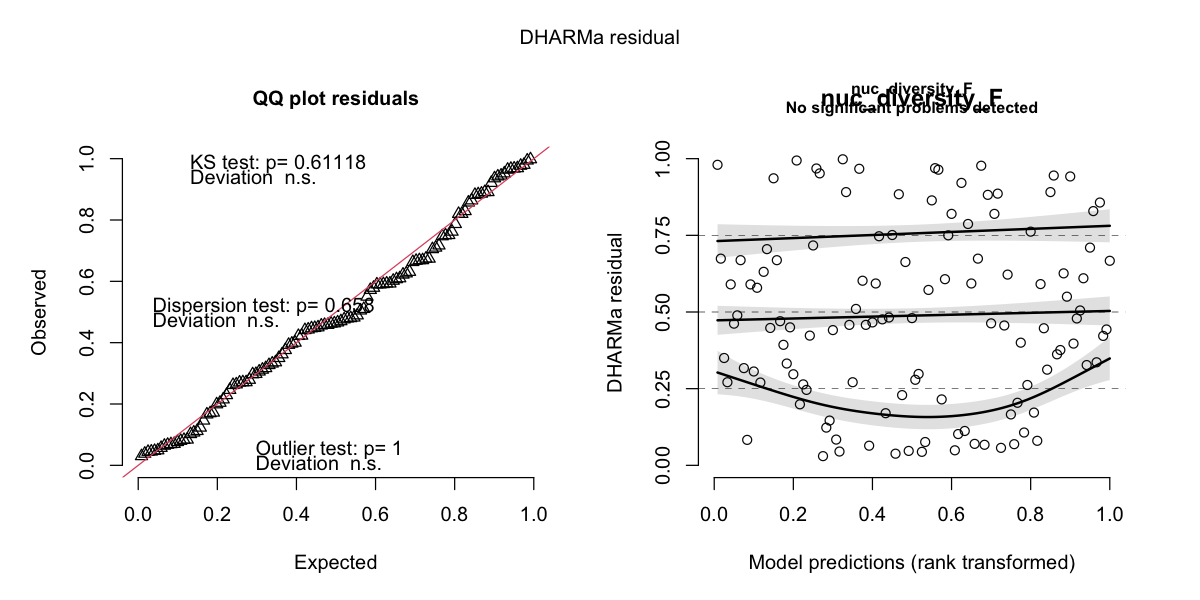


Model: nuc_diversity_RSV_A 


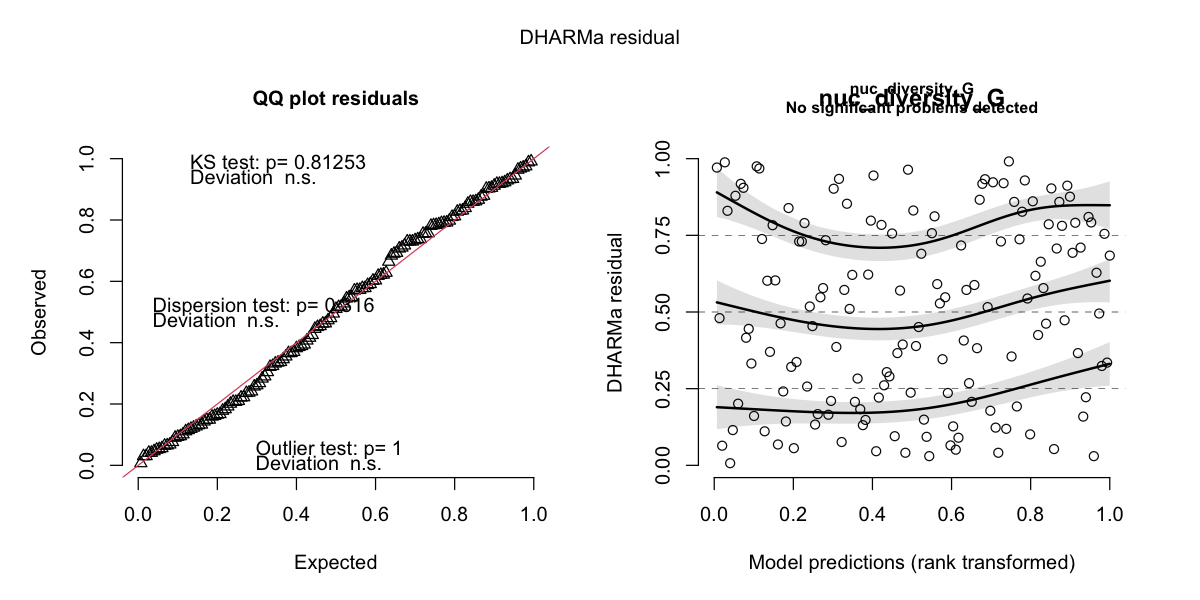


Model: nuc_diversity_RSV_B 


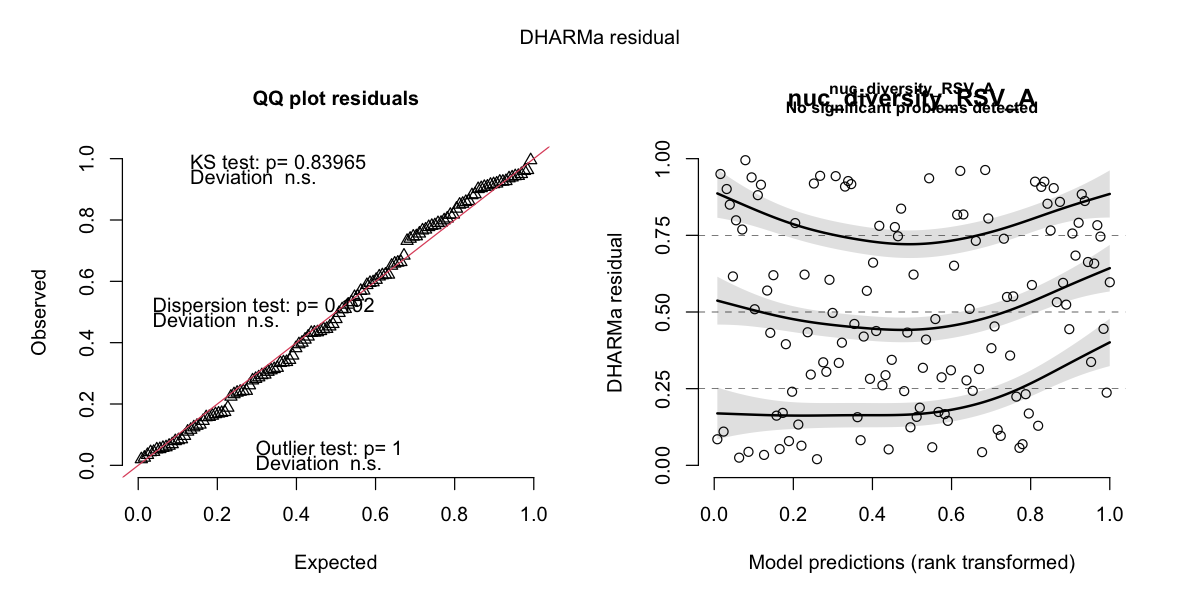


Model: richness_RSV_A 


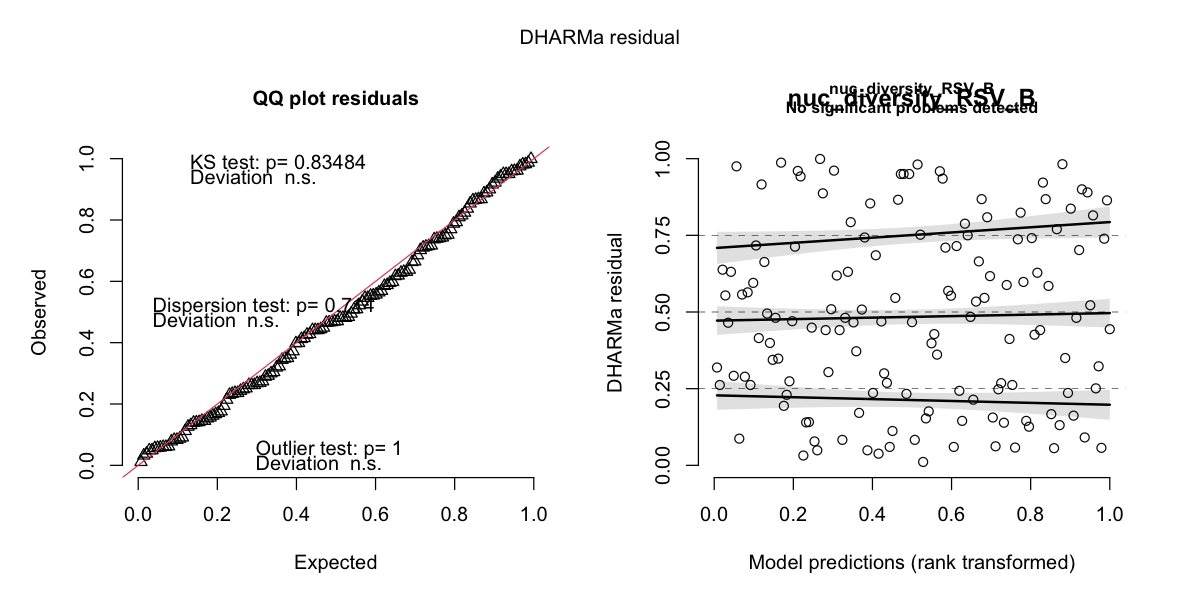


Model: richness_RSV_B 


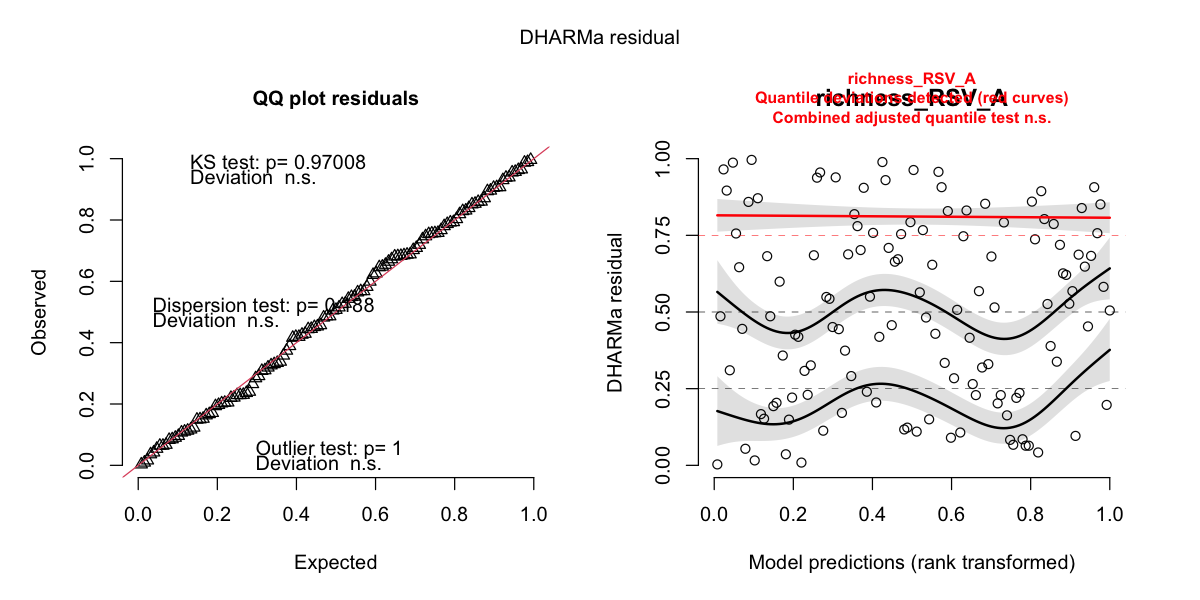

                                                             model       test
uniformity.D...1                         nuc_diversity_full_genome uniformity
dispersion.dispersion...2                nuc_diversity_full_genome dispersion
outliers.outliers at both margin(s)...3  nuc_diversity_full_genome   outliers
zero_infl.ratioObsSim...4                nuc_diversity_full_genome  zero_infl
uniformity.D...5                                   nuc_diversity_F uniformity
dispersion.dispersion...6                          nuc_diversity_F dispersion
outliers.outliers at both margin(s)...7            nuc_diversity_F   outliers
zero_infl.ratioObsSim...8                          nuc_diversity_F  zero_infl
uniformity.D...9                                   nuc_diversity_G uniformity
dispersion.dispersion...10                         nuc_diversity_G dispersion
outliers.outliers at both margin(s)...11           nuc_diversity_G   outliers
zero_infl.ratioObsSim...12                         nuc_diversity

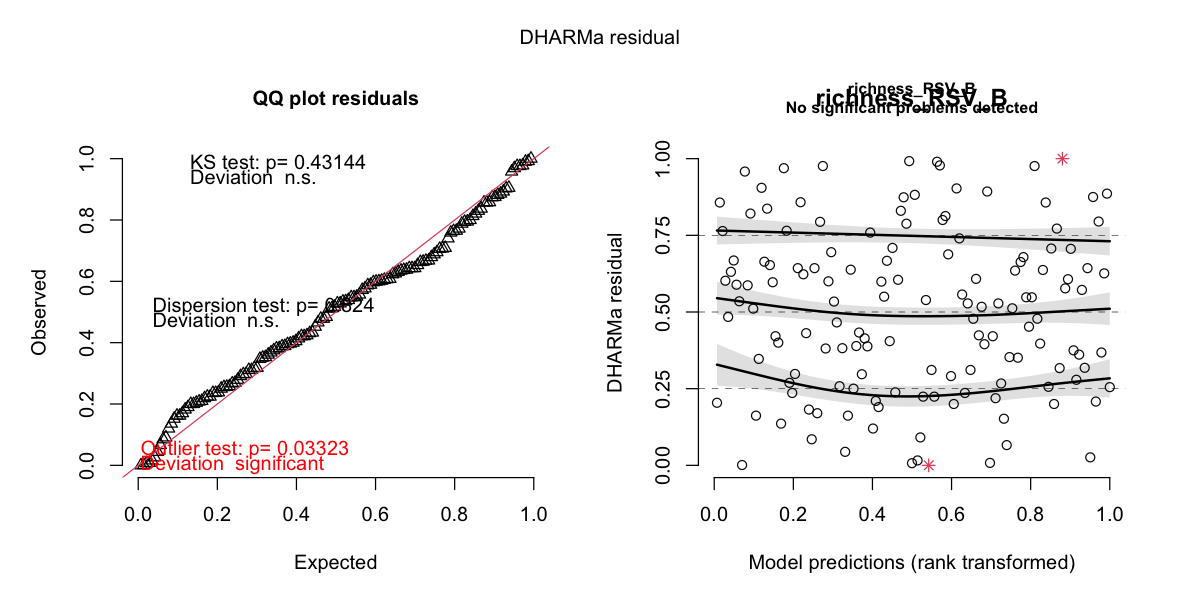

In [20]:
options(repr.plot.width = 10, repr.plot.height = 5)


# Run diagnostics for all models at once
run_diagnostics <- function(model, model_name) {
  
  cat("\n==============================\n")
  cat("Model:", model_name, "\n")
  cat("==============================\n")
  
  sim_res <- simulateResiduals(model, n = 1000)
  
  # Main plot — uniformity + dispersion + outliers
  plot(sim_res, main = model_name)
    

  # Individual tests
  tests <- list(
    uniformity  = testUniformity(sim_res,  plot = FALSE),
    dispersion  = testDispersion(sim_res,  plot = FALSE),
    outliers    = testOutliers(sim_res,    plot = FALSE),
    zero_infl   = testZeroInflation(sim_res, plot = FALSE)
  )
  
  # Summarise as data frame
  data.frame(
    model       = model_name,
    test        = names(tests),
    statistic   = sapply(tests, function(t) round(t$statistic, 4)),
    p_value     = sapply(tests, function(t) round(t$p.value, 4)),
    problem     = sapply(tests, function(t) t$p.value < 0.05)
  )
}

# Apply to all models
all_models <- c(genome_models, gene_models, subtype_models)

diag_results <- bind_rows(
  lapply(names(all_models), function(n) {
    run_diagnostics(all_models[[n]], n)
  })
)

print(diag_results)

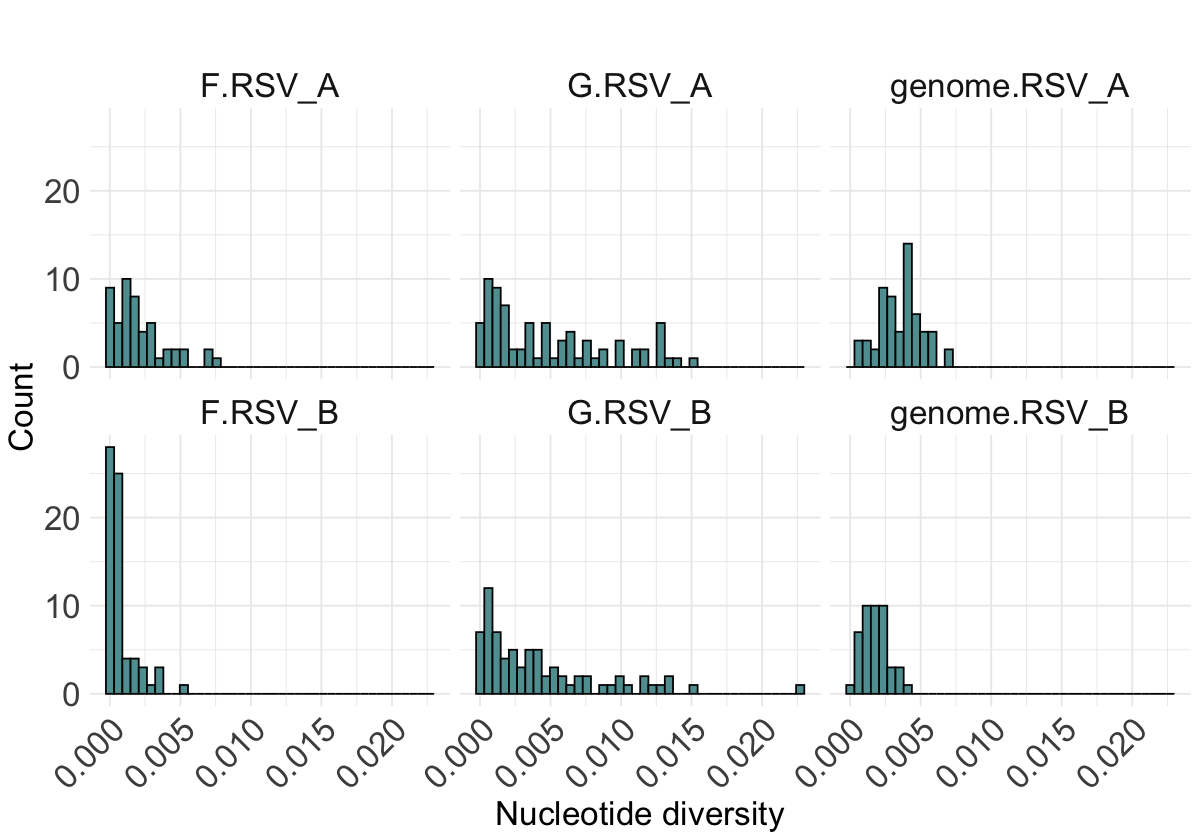

In [21]:
options(repr.plot.width = 10, repr.plot.height = 7)
# G and F diversity
ggplot(rsv_div_matrix, aes(x = nuc_diversity, color=subtype)) +
  geom_histogram(bins = 40, fill = "cadetblue", color = "black") +
facet_wrap(~ interaction(genome_region, subtype))+
  labs(title = "",
       x = "Nucleotide diversity", y = "Count") +
  theme_minimal() +
  theme(
    legend.position = "right",
    strip.text = element_text(size = 20),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20),

    axis.text = element_text(size = 20),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 28, hjust = 0.5))



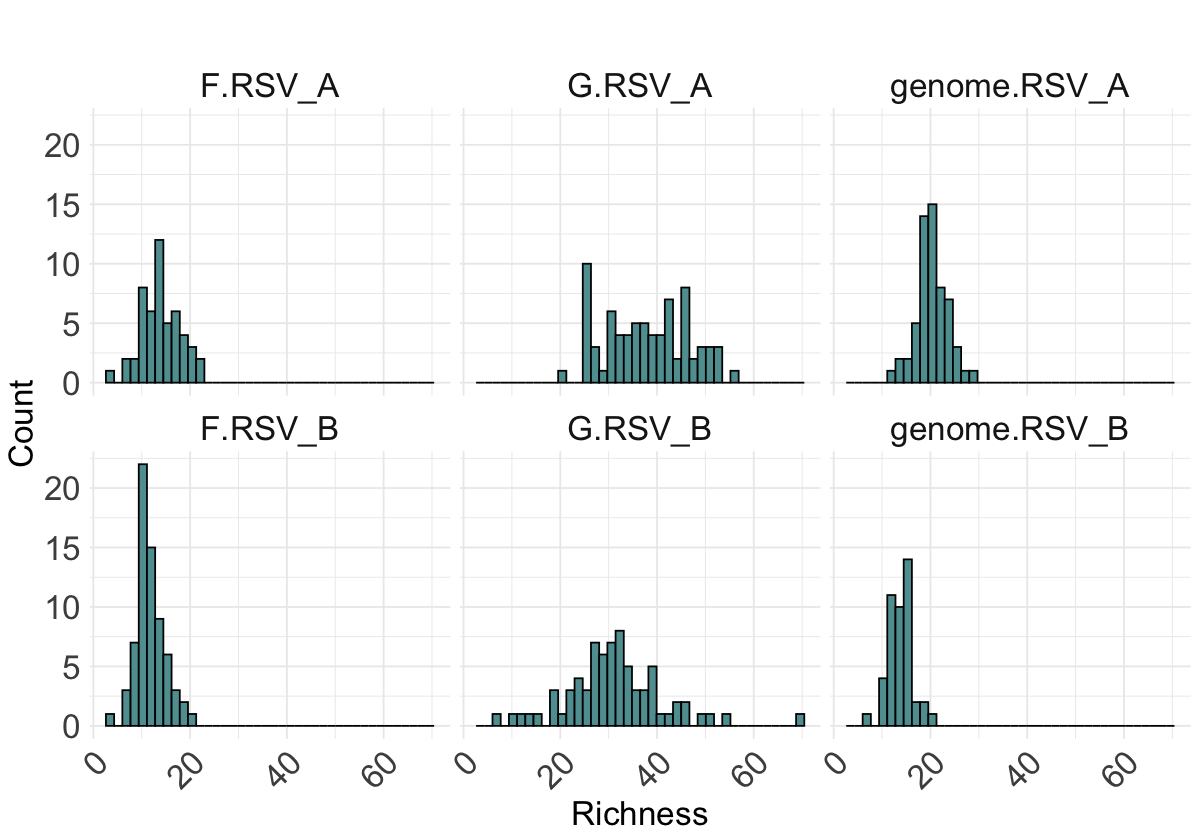

In [22]:

options(repr.plot.width = 10, repr.plot.height = 7)
# G and F diversity
ggplot(rsv_div_matrix, aes(x = richness, color=subtype)) +
  geom_histogram(bins = 40, fill = "cadetblue", color = "black") +
facet_wrap(~ interaction(genome_region, subtype))+
  labs(title = "",
       x = "Richness", y = "Count") +
  theme_minimal() +
  theme(
    legend.position = "right",
    strip.text = element_text(size = 20),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20),

    axis.text = element_text(size = 20),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 28, hjust = 0.5))



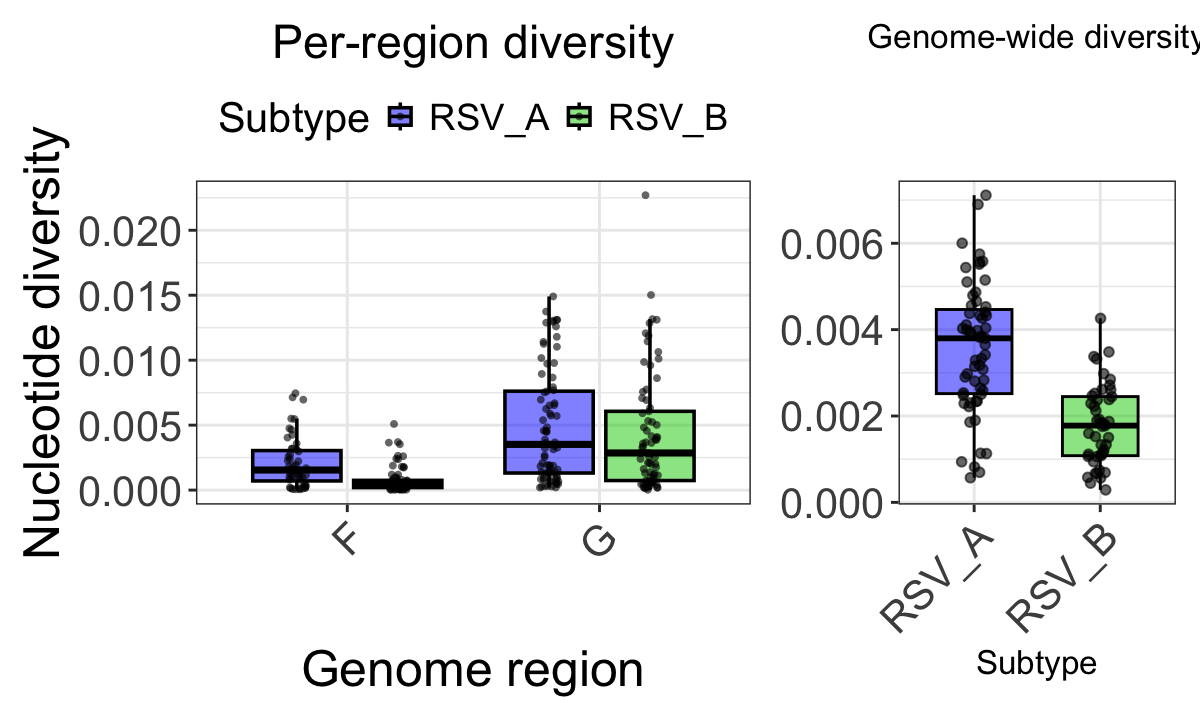

In [23]:
options(repr.plot.width = 10, repr.plot.height = 6)

# Add facet grouping
rsv_div_matrix <- rsv_div_matrix %>%
  mutate(
    facet_group = ifelse(genome_region == "genome", "Genome-wide", "Per-region")
  )

# --- Per-region plot ---
p_regions2 <- rsv_div_matrix %>%
  filter(facet_group == "Per-region") %>%
  ggplot(aes(x = genome_region, y = nuc_diversity, fill = subtype)) +
  geom_boxplot(
    position = position_dodge(width = 0.8),
    outlier.shape = NA,
    linewidth = 1,
    width = 0.7,
    colour = "black",
    alpha = 0.5
  ) +
  geom_jitter(
    position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.8),
    alpha = 0.6, size = 2.2, stroke = 0
  ) +
  scale_fill_manual(values = c("RSV_A" = "blue", "RSV_B" = "green3")) +
  labs(
    x = "Genome region",
    y = "Nucleotide diversity",
    title = "Per-region diversity",
    fill = "Subtype"
  ) +
  theme_bw(base_size = 18) +
  theme(
    legend.position = "top",
    strip.text = element_text(size = 26),
    strip.background = element_rect(fill = "grey90", color = "black"),
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 25),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 28, hjust = 0.5),
    legend.title = element_text(size = 25),
    legend.text = element_text(size = 22)
  ) 

# --- Genome-wide plot ---
p_genome2 <- rsv_div_matrix %>%
  filter(facet_group == "Genome-wide") %>%
  ggplot(aes(x = subtype, y = nuc_diversity, fill = subtype)) +
  geom_boxplot(width = 0.6, colour = "black", alpha = 0.5) +
  geom_jitter(width = 0.1, alpha = 0.6, size = 2.2) +
  scale_fill_manual(values = c("RSV_A" = "blue", "RSV_B" = "green3")) +
  labs(
    x = "Subtype",
    y = NULL,
    title = "Genome-wide diversity",
    fill = "Subtype"
  ) +
  theme_bw(base_size = 18) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 23),
    axis.title.x = element_text(size = 20,),
    axis.text = element_text(size = 25),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 20, hjust = 0.5))



# --- Combine with custom widths ---
p_final <- p_regions2 + p_genome2 + plot_layout(widths = c(2, 1))
p_final


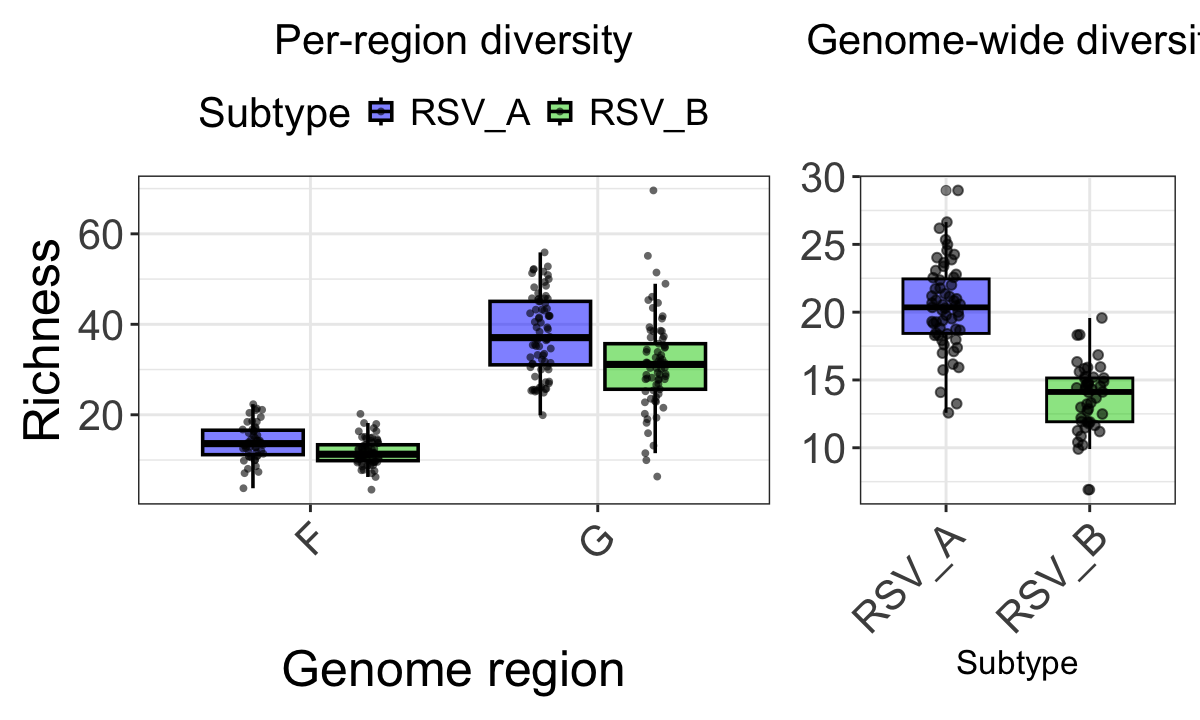

In [24]:
options(repr.plot.width = 10, repr.plot.height =6)

# Add facet grouping
rsv_div_matrix <- rsv_div_matrix %>%
  mutate(
    facet_group = ifelse(genome_region == "genome", "Genome-wide", "Per-region")
  )

# --- Per-region plot ---
p_regions3 <- rsv_div_matrix %>%
  filter(facet_group == "Per-region") %>%
  ggplot(aes(x = genome_region, y = richness, fill = subtype)) +
  geom_boxplot(
    position = position_dodge(width = 0.8),
    outlier.shape = NA,
    linewidth = 1,
    width = 0.7,
    colour = "black",
    alpha = 0.5
  ) +
  geom_jitter(
    position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.8),
    alpha = 0.6, size = 2.2, stroke = 0
  ) +
  scale_fill_manual(values = c("RSV_A" = "blue", "RSV_B" = "green3")) +
  labs(
    x = "Genome region",
    y = "Richness",
    title = "Per-region diversity",
    fill = "Subtype"
  ) +
  theme_bw(base_size = 18) +
  theme(
    legend.position = "top",
    strip.text = element_text(size = 23),
    strip.background = element_rect(fill = "grey90", color = "black"),
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 25),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 25, hjust = 0.5),
    legend.title = element_text(size = 25),
    legend.text = element_text(size = 22)
  ) 

# --- Genome-wide plot ---
p_genome3 <- rsv_div_matrix %>%
  filter(facet_group == "Genome-wide") %>%
  ggplot(aes(x = subtype, y = richness, fill = subtype)) +
  geom_boxplot(width = 0.6, colour = "black", alpha = 0.5) +
  geom_jitter(width = 0.1, alpha = 0.6, size = 2.2) +
  scale_fill_manual(values = c("RSV_A" = "blue", "RSV_B" = "green3")) +
  labs(
    x = "Subtype",
    y = NULL,
    title = "Genome-wide diversity",
    fill = "Subtype"
  ) +
  theme_bw(base_size = 18) +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 23),
    axis.title.x = element_text(size = 20),
    axis.text = element_text(size = 25),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(size = 25, hjust = 0.5),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 20))


# --- Combine with custom widths ---
p_final <- p_regions3 + p_genome3 + plot_layout(widths = c(2, 1))
p_final


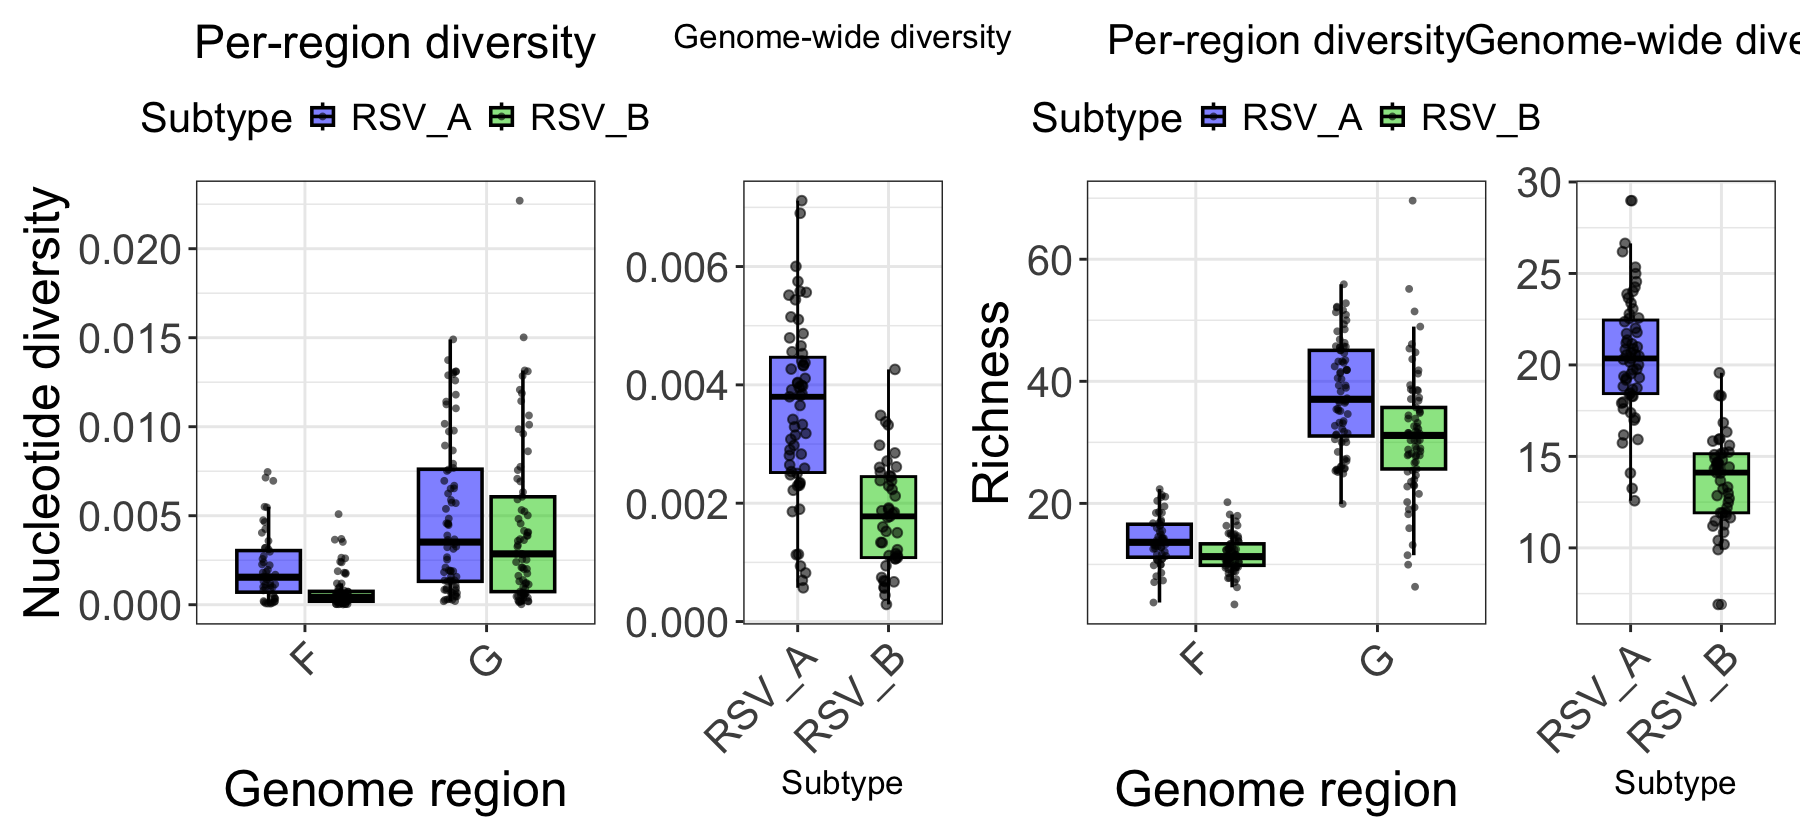

In [25]:
options(repr.plot.width = 15, repr.plot.height =7)

figC <- p_regions2 + p_genome2 + p_regions3 + p_genome3 +  plot_layout(widths = c(2,1,2,1))
figC
ggsave("Figure4_C.pdf", figC, width = 14, height = 8)
